<a href="https://colab.research.google.com/github/julietapgomez/Data-Science-III/blob/main/Proyecto_Final_DS_III_Julieta_Gomez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Clasificación automática de sentimiento en reseñas de Amazon mediante NLP y Deep Learning**

## Objetivo

El presente trabajo tiene como objetivo aplicar técnicas de Procesamiento de Lenguaje Natural (NLP) y Deep Learning para clasificar automáticamente el sentimiento de reseñas de productos de Amazon.

Se busca transformar texto en representaciones numéricas mediante técnicas de vectorización y entrenar modelos capaces de predecir si una reseña expresa un sentimiento positivo, neutral o negativo.

Además, se comparará el desempeño de un modelo baseline de Machine Learning clásico (Regresión Logística) frente a modelos basados en redes neuronales, evaluando ventajas, limitaciones y capacidad de generalización.

## Hipótesis del proyecto

Con el objetivo de orientar el análisis y evaluar el comportamiento de las reseñas, se plantearon las siguientes hipótesis iniciales:

Hipótesis 1: Las reseñas negativas tienden a ser más extensas que las positivas y neutrales.

Hipótesis 2: Existen diferencias en las palabras más frecuentes según el sentimiento de las reseñas.

Hipótesis 3: Es posible clasificar automáticamente el sentimiento de una reseña utilizando técnicas de NLP y modelos predictivos.

Estas hipótesis serán evaluadas mediante análisis exploratorio de datos, procesamiento de lenguaje natural y modelos de Machine Learning y Deep Learning.

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set_style("whitegrid")

# Ignorar warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
#Carga del dataset
from google.colab import files
uploaded = files.upload()

Saving amazon reviews.csv to amazon reviews (2).csv


In [3]:
import pandas as pd

df = pd.read_csv("amazon reviews.csv")

df.head()

,sentiments,cleaned_review,cleaned_review_length,review_score
0,positive,i wish would have gotten one earlier love it a...,19,5.0
1,neutral,i ve learned this lesson again open the packag...,88,1.0
2,neutral,it is so slow and lags find better option,9,2.0
3,neutral,roller ball stopped working within months of m...,12,1.0
4,neutral,i like the color and size but it few days out ...,21,1.0


In [4]:
df.columns

Index(['sentiments', 'cleaned_review', 'cleaned_review_length',
       'review_score'],
      dtype='object')

In [5]:
df.shape

(17340, 4)

In [6]:
df.describe(include="all")

,sentiments,cleaned_review,cleaned_review_length,review_score
count,17340,17337,17340.000000,17340.000000
unique,3,13193,NaN,NaN
top,positive,works great,NaN,NaN
freq,9503,45,NaN,NaN
mean,NaN,NaN,30.300461,3.649077
std,NaN,NaN,35.836540,1.673500
min,NaN,NaN,0.000000,1.000000
25%,NaN,NaN,9.000000,2.000000
50%,NaN,NaN,20.000000,5.000000
75%,NaN,NaN,38.000000,5.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17340 entries, 0 to 17339
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sentiments             17340 non-null  object 
 1   cleaned_review         17337 non-null  object 
 2   cleaned_review_length  17340 non-null  int64  
 3   review_score           17340 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 542.0+ KB


## Exploración inicial del dataset

El dataset contiene reseñas de productos de Amazon junto con su clasificación de sentimiento. Se observa la presencia de variables textuales y numéricas, incluyendo el texto procesado de la reseña, longitud textual y score de valoración.

Durante esta etapa se verificó la estructura general de los datos, cantidad de registros, tipos de variables y posibles valores faltantes.

In [8]:
#Ver desbalance
df["sentiments"].value_counts()

,count
sentiments,
positive,9503
neutral,6303
negative,1534


In [9]:
df["sentiments"].value_counts(normalize=True) * 100

,proportion
sentiments,
positive,54.803922
neutral,36.349481
negative,8.846597


## Distribución de clases

Se observa un desbalance en las clases del dataset, predominando las reseñas positivas (54,8%), seguidas por las neutrales (36,3%) y, en menor proporción, las negativas (8,8%).

Este comportamiento puede influir en el desempeño de los modelos predictivos, favoreciendo una mayor precisión sobre las clases más representadas y dificultando la detección de categorías minoritarias, especialmente las reseñas negativas.

In [10]:
df.isnull().sum()

,0
sentiments,0
cleaned_review,3
cleaned_review_length,0
review_score,0


In [11]:
df = df.dropna()

In [12]:
df.isnull().sum()

,0
sentiments,0
cleaned_review,0
cleaned_review_length,0
review_score,0


Se observa una distribución desbalanceada de clases, predominando las reseñas positivas, seguidas por las neutrales y, en menor medida, las negativas. Este comportamiento podría influir en el desempeño de los modelos predictivos, favoreciendo una mayor precisión sobre las clases más representadas

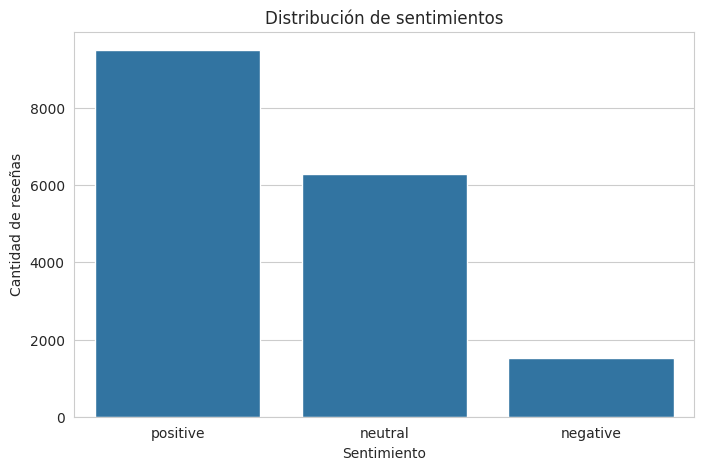

In [13]:
#Visualizacion de Clases
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="sentiments"
)

plt.title("Distribución de sentimientos")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de reseñas")

plt.show()

In [14]:
df["review_length"] = df["cleaned_review"].astype(str).apply(len)

In [15]:
df["review_length"].describe()

,review_length
count,17337.000000
mean,161.011882
std,191.123876
min,1.000000
25%,48.000000
50%,104.000000
75%,204.000000
max,3252.000000


## Frecuencia de palabras más comunes

Además de analizar la distribución de clases, se realizó un análisis de frecuencia de palabras con el objetivo de identificar los términos más repetidos dentro de las reseñas.

Este análisis permite detectar patrones generales del lenguaje utilizado por los usuarios y comprender qué conceptos aparecen con mayor recurrencia en las opiniones.

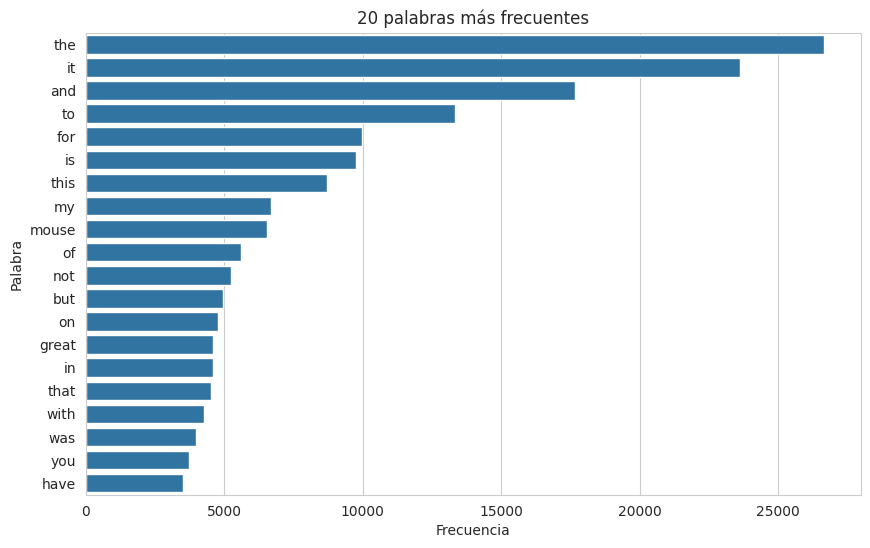

In [16]:
from collections import Counter

# Unir todo el texto
all_words = " ".join(
    df["cleaned_review"]
    .dropna()
    .astype(str)
).split()

# Contar frecuencia
word_freq = Counter(all_words)

# Top 20 palabras
top_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=["Palabra", "Frecuencia"]
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_words,
    x="Frecuencia",
    y="Palabra"
)

plt.title("20 palabras más frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")

plt.show()

Se observó una alta frecuencia de términos vinculados con experiencia de compra, funcionamiento y calidad de producto, lo cual resulta consistente con el dominio de reseñas de Amazon.

Este comportamiento permite inferir que gran parte de las opiniones se concentran en evaluar desempeño, utilidad y satisfacción del producto adquirido.

## Análisis de longitud textual

La longitud de las reseñas presenta una distribución asimétrica positiva (sesgada hacia la derecha), observándose una alta concentración de textos cortos y medianos, junto con algunos casos extremos de reseñas muy extensas.

Esto sugiere que la mayoría de los usuarios expresan opiniones relativamente breves, aunque ciertos casos contienen explicaciones mucho más detalladas.

---



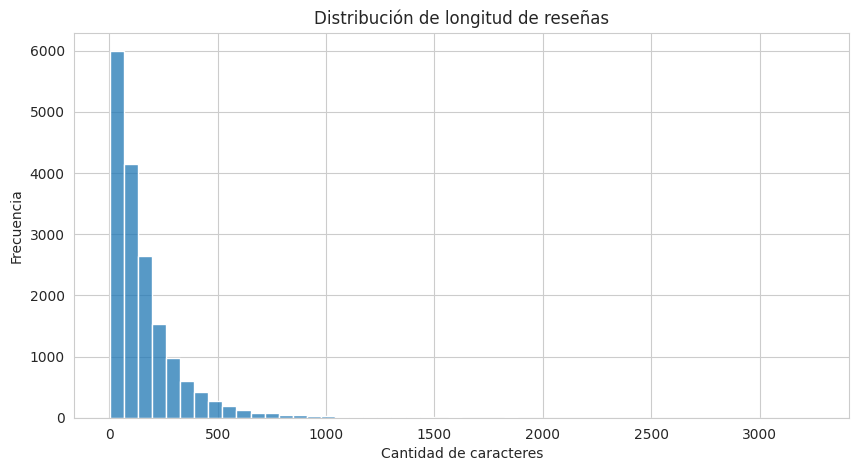

In [17]:
#Histograma de Distribución de longitud de reseñas
plt.figure(figsize=(10,5))

sns.histplot(
    df["review_length"],
    bins=50
)

plt.title("Distribución de longitud de reseñas")
plt.xlabel("Cantidad de caracteres")
plt.ylabel("Frecuencia")

plt.show()

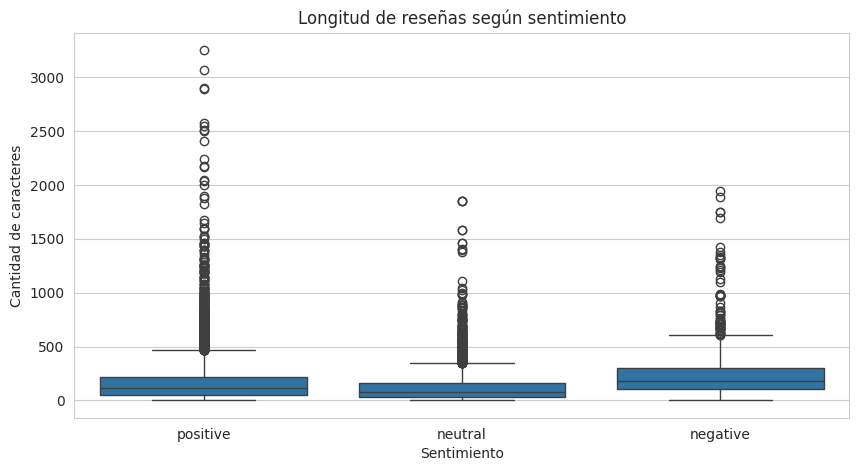

In [18]:
#Longitud por sentimiento
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="sentiments",
    y="review_length"
)

plt.title("Longitud de reseñas según sentimiento")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de caracteres")

plt.show()

## Longitud textual según sentimiento

Se observa que las reseñas negativas presentan, en promedio, una mayor longitud textual respecto de las neutrales y positivas.

Esto podría sugerir que los usuarios insatisfechos tienden a brindar explicaciones más detalladas de su experiencia, mientras que las reseñas positivas suelen expresarse de manera más breve y directa.

In [19]:
df.groupby("sentiments")["review_length"].describe()

,count,mean,std,min,25%,50%,75%,max
sentiments,,,,,,,,
negative,1534.0,235.078227,211.397362,3.0,102.0,175.0,303.0,1944.0
neutral,6300.0,120.925397,136.456292,1.0,35.0,81.0,160.0,1852.0
positive,9503.0,175.631169,211.957812,4.0,52.0,111.0,218.0,3252.0


In [20]:
df["cleaned_review"].sample(10, random_state=42)

,cleaned_review
14785,it meets my need
14534,i shopped around for while great speaker sound...
16246,why there no lights or showing if it charged o...
6385,it had connectivity issues right out of the bo...
424,don buy it for one is very inconvenient rechar...
12243,you get what you pay for hold true with this p...
7657,love this mouse mouse came days before deliver...
4610,the mouse is not effective charged for hours s...
7578,worked great for about week now won work love ...
10405,no complaints


# Procesamiento de Lenguaje Natural (NLP)

Con el objetivo de preparar el texto para el modelado predictivo, se aplicó un pipeline de preprocesamiento NLP sobre las reseñas.

Las etapas incluyeron:

- Conversión a minúsculas
- Tokenización
- Eliminación de stopwords
- Filtrado de palabras no alfabéticas
- Lematización

El objetivo de estas transformaciones es reducir ruido textual y conservar información relevante para el proceso de clasificación.

### Limpieza textual mediante Regex

Antes del proceso de tokenización, se aplicó una limpieza inicial utilizando expresiones regulares (Regex), con el objetivo de eliminar caracteres especiales, puntuación y números, conservando únicamente caracteres alfabéticos relevantes para el análisis semántico.

In [21]:
import re

def clean_text_regex(text):

    text = str(text)

    # conservar letras y espacios
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # minúsculas
    text = text.lower()

    return text

df["regex_review"] = (
    df["cleaned_review"]
    .apply(clean_text_regex)
)

df[
    ["cleaned_review",
     "regex_review"]
].head()

,cleaned_review,regex_review
0,i wish would have gotten one earlier love it a...,i wish would have gotten one earlier love it a...
1,i ve learned this lesson again open the packag...,i ve learned this lesson again open the packag...
2,it is so slow and lags find better option,it is so slow and lags find better option
3,roller ball stopped working within months of m...,roller ball stopped working within months of m...
4,i like the color and size but it few days out ...,i like the color and size but it few days out ...


In [31]:
# NLTK completo: configuración + función + aplicación

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("punkt_tab")
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()

    tokens = word_tokenize(text)

    filtered_tokens = [
        word for word in tokens
        if word.isalpha() and word not in stop_words
    ]

    lemmatized_tokens = [
        lemmatizer.lemmatize(word)
        for word in filtered_tokens
    ]

    return " ".join(lemmatized_tokens)

df = df.dropna(subset=["regex_review"]).copy()

df["processed_review"] = df["regex_review"].apply(preprocess_text)

df[["cleaned_review", "processed_review"]].sample(10, random_state=42)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,cleaned_review,processed_review
14785,it meets my need,meet need
14534,i shopped around for while great speaker sound...,shopped around great speaker sound excellent h...
16246,why there no lights or showing if it charged o...,light showing charged turn see light see charg...
6385,it had connectivity issues right out of the bo...,connectivity issue right box contacted seller ...
424,don buy it for one is very inconvenient rechar...,buy one inconvenient rechargeable never know m...
12243,you get what you pay for hold true with this p...,get pay hold true product senior citizen fixed...
7657,love this mouse mouse came days before deliver...,love mouse mouse came day delivery eta always ...
4610,the mouse is not effective charged for hours s...,mouse effective charged hour still life functi...
7578,worked great for about week now won work love ...,worked great week work love color quiet click ...
10405,no complaints,complaint


### Comparación de lematización: NLTK vs spaCy

Con el objetivo de comparar enfoques de preprocesamiento lingüístico, se implementó una segunda estrategia de lematización utilizando spaCy.

Esto permitió contrastar diferencias en la normalización textual respecto al pipeline implementado con NLTK.

Se observa cómo el texto original es simplificado eliminando palabras poco informativas y reduciendo variaciones lingüísticas a una forma base (lematización), conservando principalmente términos con contenido semántico relevante.

In [82]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 78.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [32]:
import spacy

nlp = spacy.load("en_core_web_sm")

In [34]:
sample_spacy = df.sample(500, random_state=42).copy()

sample_spacy["processed_review_spacy"] = sample_spacy["regex_review"].apply(preprocess_spacy)

sample_spacy[
    [
        "cleaned_review",
        "processed_review",
        "processed_review_spacy"
    ]
].sample(10, random_state=42)

,cleaned_review,processed_review,processed_review_spacy
937,i bought one of these and in three months it c...,bought one three month completely stopped work...,buy month completely stop work couldn charge u...
900,scroll is not working properly after months of...,scroll working properly month usage undoubtedl...,scroll work properly month usage undoubtedly b...
17226,like everything about it,like everything,like
17311,excelente,excelente,excelente
11902,works great with macbook pro thanks,work great macbook pro thanks,work great macbook pro thank
5515,love how it looks when it changes colors comes...,love look change color come adapter charging c...,love look change color come adapter charge cor...
361,had this mouse for about month and the center ...,mouse month center wheel broke scrolling used ...,mouse month center wheel break scroll daily work
17102,exactly what wanted great sound battery lasts ...,exactly wanted great sound battery last forever,exactly want great sound battery last forever
4131,the mouse only works if directly next to the u...,mouse work directly next usb port plugged usel...,mouse work directly usb port plug useless foot...
8875,the blacklighting is not nearly as bright as h...,blacklighting nearly bright hoped feel like wo...,blacklighting nearly bright hop don feel like ...


Se comparó la lematización realizada con NLTK y spaCy sobre una muestra de 500 reseñas. Se observan resultados similares en términos generales, aunque spaCy incorpora un análisis lingüístico más contextualizado. Para el modelado final se decidió continuar con la columna `processed_review` generada mediante NLTK, priorizando simplicidad y menor costo computacional.

In [36]:
#convertir texto en números con TF-IDF.

#Separar variables: X es el texto procesado e y es lo que quiero predecir.

X = df["processed_review"]
y = df["sentiments"]

# Vectorización del texto

Los algoritmos de Machine Learning y Deep Learning no pueden procesar texto directamente, por lo que fue necesario convertir las reseñas en representaciones numéricas.

Para ello se utilizó TF-IDF (Term Frequency - Inverse Document Frequency), técnica que pondera la importancia de cada palabra considerando tanto su frecuencia en una reseña como su rareza en el conjunto total de documentos.

In [38]:
# Separar variables
X = df["processed_review"]
y = df["sentiments"]

# Separar entrenamiento y test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
#Vectorizar con TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


#Aclaración
#max_features=5000 limita el vocabulario a las 5000 palabras/frases más relevantes.
#ngram_range=(1,2) considera palabras individuales y pares de palabra

In [38]:
#Ver la forma de la matriz

#filas = reseñas
#columnas = términos TF-IDF

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(13869, 5000)
(3468, 5000)


Se utilizó TF-IDF para transformar las reseñas procesadas en una matriz numérica.

La configuración incluyó:

- `max_features=5000`: limita el vocabulario a los términos más relevantes.
- `ngram_range=(1,2)`: incorpora unigramas y bigramas, permitiendo capturar tanto palabras individuales como combinaciones frecuentes.

Esto permite representar el lenguaje en formato numérico preservando parte de la estructura textual.

### Justificación del uso de TF-IDF

Se seleccionó TF-IDF en lugar de un simple conteo de palabras (Bag of Words), debido a que esta técnica pondera la importancia relativa de cada término dentro del corpus.

Mientras Bag of Words asigna el mismo peso a todas las palabras frecuentes, TF-IDF reduce la influencia de términos muy comunes y destaca aquellos más informativos para la clasificación.

Esto resulta especialmente útil en tareas de análisis de sentimiento, donde ciertas palabras específicas poseen mayor capacidad discriminativa entre opiniones positivas, negativas y neutrales.

## **Aplicación del primer modelo baseline: Regresión Logística**


Antes de implementar modelos de Deep Learning, se entrenó un modelo baseline basado en Regresión Logística.

Este algoritmo es ampliamente utilizado en clasificación textual debido a su interpretabilidad, rapidez y buen desempeño sobre representaciones TF-IDF, permitiendo establecer un punto de comparación inicial.

In [39]:
from sklearn.linear_model import LogisticRegression

# Crear modelo
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Entrenar
log_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

El modelo baseline fue entrenado sobre la representación TF-IDF con el objetivo de aprender patrones lingüísticos asociados a cada categoría de sentimiento (positivo, neutral y negativo).

In [40]:
#Predicciones

y_pred = log_model.predict(X_test_tfidf)

In [41]:
#Accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8356401384083045


Si bien el modelo tiene un accuracy bastante elevado, el dataset está desbalanceado debido a que tiene muchos reviews positivos, por lo que se necesitan otras métricas de clasificación

In [42]:
#Classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.77      0.33      0.46       307
     neutral       0.77      0.84      0.80      1260
    positive       0.89      0.92      0.90      1901

    accuracy                           0.84      3468
   macro avg       0.81      0.69      0.72      3468
weighted avg       0.83      0.84      0.83      3468



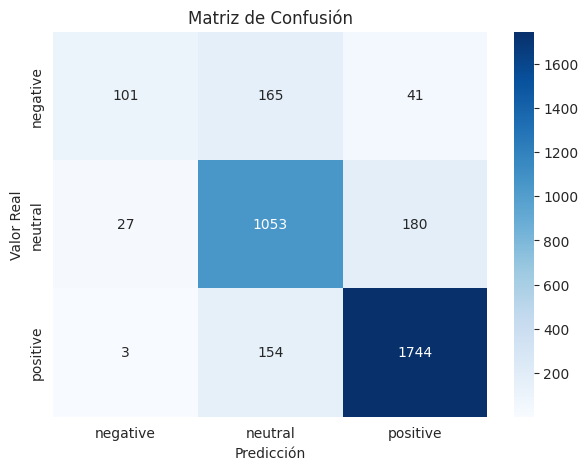

In [43]:
#Matriz de confusión

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=log_model.classes_,
    yticklabels=log_model.classes_
)

plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

El modelo baseline alcanzó un accuracy aproximado del 83,5%, mostrando un desempeño sólido en la clasificación de reseñas positivas y neutrales.

Sin embargo, se observó una baja capacidad para identificar reseñas negativas reales, reflejada en un recall reducido para esta clase.

Esto podría explicarse tanto por el desbalance presente en el dataset como por las limitaciones de TF-IDF para capturar contexto, ironías o negaciones complejas del lenguaje.

In [63]:
from sklearn.linear_model import LogisticRegression

log_model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

log_model_balanced.fit(X_train_tfidf, y_train)

y_pred_balanced = log_model_balanced.predict(X_test_tfidf)

In [64]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

    negative       0.55      0.77      0.64       307
     neutral       0.79      0.79      0.79      1260
    positive       0.92      0.86      0.89      1901

    accuracy                           0.83      3468
   macro avg       0.76      0.81      0.78      3468
weighted avg       0.84      0.83      0.83      3468



Resultados del modelo balanceado

La incorporación de ponderación de clases permitió mejorar parcialmente la detección de categorías minoritarias, particularmente las reseñas negativas, reduciendo el sesgo generado por el desbalance del dataset.

# Ajuste del desbalance de clases

Debido al predominio de reseñas positivas en el dataset, se entrenó una segunda versión del modelo baseline incorporando ponderación automática de clases (class_weight='balanced').

Esto permite penalizar menos las clases minoritarias y mejorar la detección de reseñas negativas.

# Validación cruzada del modelo baseline

Con el objetivo de verificar la estabilidad del modelo baseline y reducir el sesgo asociado a una única división del dataset, se aplicó validación cruzada (Cross Validation) con 5 particiones.

Esto permite evaluar el desempeño promedio del modelo sobre diferentes subconjuntos del dataset.

In [62]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

log_model_cv = LogisticRegression(
    max_iter=1000,
    random_state=42
)

cv_scores = cross_val_score(
    log_model_cv,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Accuracy promedio:", cv_scores.mean())
print("Scores:", cv_scores)

Accuracy promedio: 0.8283940230115769
Scores: [0.82191781 0.83453497 0.82335977 0.8370584  0.82509917]


Interpretación de la validación cruzada

La validación cruzada permitió comprobar que el modelo baseline mantiene un rendimiento relativamente estable en distintas divisiones del dataset, reduciendo el riesgo de sobreajuste a una única partición de entrenamiento y prueba.

# Optimización de hiperparámetros

Con el objetivo de explorar mejoras en el modelo baseline, se aplicó una búsqueda de hiperparámetros mediante GridSearchCV.

Se evaluaron distintos valores de regularización para identificar la configuración con mejor desempeño.

In [65]:
from sklearn.model_selection import GridSearchCV

params = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear']
}

grid = GridSearchCV(
    LogisticRegression(),
    params,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train_tfidf, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor score:", grid.best_score_)

Mejores parámetros: {'C': 10, 'solver': 'liblinear'}
Mejor score: 0.8366140312928113


Resultados de optimización

La optimización permitió identificar la combinación de hiperparámetros con mejor rendimiento dentro del espacio evaluado.

No obstante, las mejoras obtenidas fueron moderadas, lo que sugiere que la representación TF-IDF ya proporciona un desempeño competitivo para este problema.

## **Deep Learning**

# Modelo 1



Con el objetivo de evaluar posibles mejoras respecto del baseline, se implementaron modelos de Deep Learning utilizando redes neuronales densas.

El propósito es analizar si arquitecturas más complejas logran capturar patrones lingüísticos adicionales presentes en las reseñas.

In [42]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping

In [43]:
#Conversión de clases a números

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

['negative' 'neutral' 'positive']


In [44]:
#Creación Modelo 1
model_1 = Sequential([
    Dense(
        64,
        activation='relu',
        input_shape=(X_train_tfidf.shape[1],)
    ),
    Dense(
        3,
        activation='softmax'
    )
])

In [45]:
#Compilar

model_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [46]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [47]:
#Resumen del modelo

model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       320,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,259 (1.22 MB)

 Trainable params: 320,259 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
#Entrenar el modelo
history_1 = model_1.fit(
    X_train_tfidf.toarray(),
    y_train_encoded,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.7052 - loss: 0.6968 - val_accuracy: 0.7765 - val_loss: 0.5302
Epoch 2/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8543 - loss: 0.3860 - val_accuracy: 0.8151 - val_loss: 0.4506
Epoch 3/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9132 - loss: 0.2601 - val_accuracy: 0.8230 - val_loss: 0.4451
Epoch 4/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9429 - loss: 0.1867 - val_accuracy: 0.8345 - val_loss: 0.4584
Epoch 5/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9633 - loss: 0.1372 - val_accuracy: 0.8367 - val_loss: 0.4878
Epoch 6/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9761 - loss: 0.1016 - val_accuracy: 0.8371 - val_loss: 0.5224
Epoch 7/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9841 - loss: 0.0770 - val_accuracy: 0.8324 - val_loss: 0.5752
Epoch 8/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9880 - loss: 0.0586 - val_accuracy:

El Modelo 1 consistió en una red neuronal simple con una capa oculta de 64 neuronas y función de activación ReLU.

Este modelo alcanzó un accuracy cercano al baseline de Regresión Logística, aunque se observó cierta diferencia entre accuracy de entrenamiento y validación, sugiriendo posible overfitting moderado.

Por este motivo, se decidió experimentar con una arquitectura más robusta incorporando regularización.

## Modelo 2

In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [50]:
model_2 = Sequential([

    Dense(
        64,
        activation='relu',
        input_shape=(X_train_tfidf.shape[1],)
    ),

    BatchNormalization(),

    Dropout(0.5),

    Dense(
        32,
        activation='relu'
    ),

    BatchNormalization(),

    Dense(
        3,
        activation='softmax'
    )
])

In [51]:
model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [52]:
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │       320,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,627 (1.23 MB)

 Trainable params: 322,435 (1.23 MB)

 Non-trainable params: 192 (768.00 B)

In [53]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [54]:
history_2 = model_2.fit(
    X_train_tfidf.toarray(),
    y_train_encoded,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.6659 - loss: 0.7553 - val_accuracy: 0.7181 - val_loss: 0.7260
Epoch 2/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8429 - loss: 0.4104 - val_accuracy: 0.8082 - val_loss: 0.4757
Epoch 3/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8898 - loss: 0.2910 - val_accuracy: 0.8381 - val_loss: 0.4535
Epoch 4/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9194 - loss: 0.2231 - val_accuracy: 0.8327 - val_loss: 0.4935
Epoch 5/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9358 - loss: 0.1762 - val_accuracy: 0.8367 - val_loss: 0.5277
Epoch 6/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9475 - loss: 0.1451 - val_accuracy: 0.8371 - val_loss: 0.5853
Epoch 7/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9511 - loss: 0.1384 - val_accuracy: 0.8244 - val_loss: 0.5958
Epoch 8/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9573 - loss: 0.1189 - val_accura

A pesar de incorporar una segunda capa oculta y regularización mediante Dropout, no se observaron mejoras drásticas en accuracy global, aunque sí se identificaron mejoras relevantes en la detección de la clase negativa, especialmente en recall.

Sin embargo, se decidió evaluar el desempeño sobre el conjunto de test para analizar si existían mejoras específicas en la detección de clases minoritarias.

# Evaluación del Modelo 2 en test

In [55]:
test_loss, test_accuracy = model_2.evaluate(
    X_test_tfidf.toarray(),
    y_test_encoded
)

print("Test Accuracy:", test_accuracy)

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8365 - loss: 0.4422
Test Accuracy: 0.8365051746368408


In [56]:
#Predicciones

y_pred_dl = model_2.predict(
    X_test_tfidf.toarray()
)

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [58]:
#Conversión de probabilidades a clases

import numpy as np

y_pred_dl_classes = np.argmax(
    y_pred_dl,
    axis=1
)

In [59]:
#Classification report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_encoded,
        y_pred_dl_classes,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

    negative       0.75      0.47      0.58       307
     neutral       0.78      0.82      0.80      1260
    positive       0.89      0.91      0.90      1901

    accuracy                           0.84      3468
   macro avg       0.80      0.73      0.76      3468
weighted avg       0.83      0.84      0.83      3468



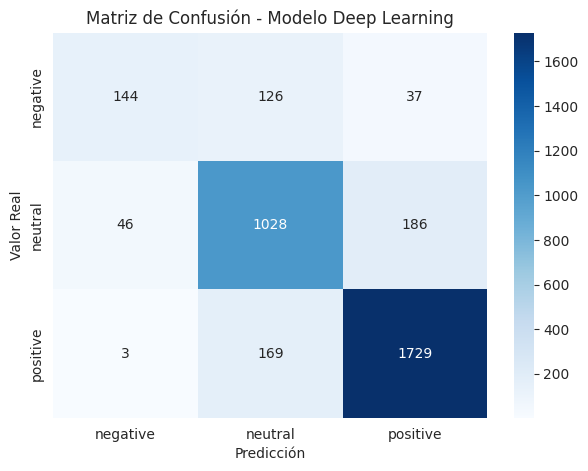

In [60]:
#Matriz de confusión

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_dl = confusion_matrix(
    y_test_encoded,
    y_pred_dl_classes
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_dl,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Matriz de Confusión - Modelo Deep Learning")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

# Limitaciones y mejoras futuras

Si bien se implementaron modelos de Deep Learning mediante redes neuronales densas, el proyecto continuó utilizando representaciones TF-IDF como entrada textual.

Esto implica que los modelos no capturan completamente relaciones contextuales complejas del lenguaje, como dependencias semánticas profundas, ironía o contexto secuencial.

Como línea futura de mejora, podrían explorarse representaciones semánticas mediante embeddings (Word2Vec, GloVe o FastText), así como arquitecturas recurrentes (LSTM, GRU) o modelos basados en Transformers, capaces de capturar mejor el significado contextual del texto.

# **Conclusión final**

El presente trabajo permitió aplicar técnicas de Procesamiento de Lenguaje Natural (NLP) y Deep Learning sobre un dataset real de reseñas de Amazon, con el objetivo de clasificar automáticamente el sentimiento de los usuarios.

En una primera instancia, se implementó un pipeline de preprocesamiento textual compuesto por limpieza mediante expresiones regulares (Regex), tokenización, eliminación de stopwords y lematización. Además, se realizó una comparación entre los enfoques de lematización de NLTK y spaCy, observándose resultados similares en la normalización textual, aunque spaCy mostró una lematización más contextualizada en algunos casos.

Posteriormente, se aplicó una representación numérica mediante TF-IDF, técnica seleccionada por su capacidad para ponderar la importancia relativa de las palabras dentro del corpus, reduciendo la influencia de términos excesivamente frecuentes y preservando información relevante para la clasificación.

Como baseline, se utilizó un modelo de Regresión Logística, obteniendo un desempeño aproximado del 83,5% de accuracy. Posteriormente, se implementaron modelos de Deep Learning utilizando redes neuronales densas con técnicas de regularización, incluyendo Batch Normalization, Dropout (p=0.5) y Early Stopping, con el objetivo de mejorar la capacidad de generalización.

El segundo modelo alcanzó un accuracy aproximado del 84%, mostrando una mejora moderada respecto al baseline. Si bien el incremento global en precisión fue limitado, se observó una mejora importante en la detección de reseñas negativas, particularmente en el recall de la clase minoritaria, aspecto relevante considerando el desbalance presente en el dataset.

Estos resultados sugieren que, para problemas de clasificación textual representados mediante TF-IDF, modelos clásicos como Regresión Logística pueden seguir siendo altamente competitivos. Sin embargo, arquitecturas de Deep Learning pueden aportar mejoras específicas en clases complejas o minoritarias, aunque con un mayor costo computacional.

Como trabajo futuro, podrían explorarse representaciones semánticas más avanzadas, como embeddings (Word2Vec, GloVe o FastText), así como arquitecturas basadas en transformers, con el objetivo de capturar mejor el contexto lingüístico y mejorar el rendimiento predictivo.